In [5]:
import pandas as pd
p = r"C:\Users\dyuti\OneDrive\Desktop\readmission_project\data\FY_2025_Hospital_Readmissions_Reduction_Program_Hospital (1).csv"
# Use low_memory=False for mixed dtypes
df = pd.read_csv(p, low_memory=False)
print("shape:", df.shape)
display(df.head().T)
print("\ncolumns:", list(df.columns))


shape: (18510, 12)


,0,1,2,3,4
Facility Name,SOUTHEAST HEALTH MEDICAL CENTER,SOUTHEAST HEALTH MEDICAL CENTER,SOUTHEAST HEALTH MEDICAL CENTER,SOUTHEAST HEALTH MEDICAL CENTER,SOUTHEAST HEALTH MEDICAL CENTER
Facility ID,10001,10001,10001,10001,10001
State,AL,AL,AL,AL,AL
Measure Name,READM-30-AMI-HRRP,READM-30-CABG-HRRP,READM-30-HF-HRRP,READM-30-HIP-KNEE-HRRP,READM-30-PN-HRRP
Number of Discharges,296.0,151.0,681.0,NaN,490.0
Footnote,NaN,NaN,NaN,NaN,NaN
Excess Readmission Ratio,0.9483,0.9509,1.0597,0.9654,0.9715
Predicted Readmission Rate,13.0146,9.6899,21.5645,4.268,16.1137
Expected Readmission Rate,13.7235,10.1898,20.3495,4.4211,16.5863
Number of Readmissions,36,13,151,Too Few to Report,77



columns: ['Facility Name', 'Facility ID', 'State', 'Measure Name', 'Number of Discharges', 'Footnote', 'Excess Readmission Ratio', 'Predicted Readmission Rate', 'Expected Readmission Rate', 'Number of Readmissions', 'Start Date', 'End Date']


In [6]:
#Clean & normalize data
df.columns = df.columns.str.strip()


In [7]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18510 entries, 0 to 18509
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Facility Name               18510 non-null  object 
 1   Facility ID                 18510 non-null  int64  
 2   State                       18510 non-null  object 
 3   Measure Name                18510 non-null  object 
 4   Number of Discharges        8340 non-null   float64
 5   Footnote                    6583 non-null   float64
 6   Excess Readmission Ratio    11927 non-null  float64
 7   Predicted Readmission Rate  11927 non-null  float64
 8   Expected Readmission Rate   11927 non-null  float64
 9   Number of Readmissions      11927 non-null  object 
 10  Start Date                  18510 non-null  object 
 11  End Date                    18510 non-null  object 
dtypes: float64(5), int64(1), object(6)
memory usage: 1.7+ MB


,Facility ID,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate
count,18510.000000,8340.000000,6583.000000,11927.000000,11927.000000,11927.000000
mean,261770.055105,279.269904,3.187756,1.001719,14.995386,14.961234
std,164647.739172,266.018069,2.089167,0.080547,5.017854,4.871997
min,10001.000000,0.000000,1.000000,0.477900,1.674200,2.892100
25%,110073.000000,115.000000,1.000000,0.956550,12.533000,12.612800
50%,250048.000000,197.000000,5.000000,0.998200,16.060200,16.146000
75%,390133.000000,354.000000,5.000000,1.043000,18.609000,18.667350
max,670327.000000,4501.000000,7.000000,1.643000,27.809500,25.394200


In [8]:
numeric_cols = [
    'Number of Discharges',
    'Excess Readmission Ratio',
    'Predicted Readmission Rate',
    'Expected Readmission Rate',
    'Number of Readmissions'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [9]:
df.isna().sum().sort_values(ascending=False)


Footnote                      11927
Number of Readmissions        10389
Number of Discharges          10170
Excess Readmission Ratio       6583
Predicted Readmission Rate     6583
Expected Readmission Rate      6583
Facility ID                       0
Facility Name                     0
Measure Name                      0
State                             0
Start Date                        0
End Date                          0
dtype: int64

In [11]:
#Average Readmission Ratio
df['Excess Readmission Ratio'].mean()


np.float64(1.0017194935859814)

In [13]:
#Average Payment Risk by Condition
df.groupby("Measure Name")['Excess Readmission Ratio'].mean().sort_values(ascending=False)

Measure Name
READM-30-HIP-KNEE-HRRP    1.003763
READM-30-AMI-HRRP         1.001909
READM-30-COPD-HRRP        1.001683
READM-30-PN-HRRP          1.001250
READM-30-HF-HRRP          1.001213
READM-30-CABG-HRRP        1.000725
Name: Excess Readmission Ratio, dtype: float64

In [15]:
#Identify Worst & Best Hospitals
#Highest Readmissions
df.sort_values('Excess Readmission Ratio', ascending=False).head(10)[
    ['Facility Name', 'State', 'Measure Name', 'Excess Readmission Ratio']
]


,Facility Name,State,Measure Name,Excess Readmission Ratio
792,ARIZONA ORTHOPEDIC AND SURGICAL SPECIALTY HOSP...,AZ,READM-30-HIP-KNEE-HRRP,1.6430
5329,LOUIS A WEISS MEMORIAL HOSPITAL,IL,READM-30-HIP-KNEE-HRRP,1.5629
4171,HCA FLORIDA OAK HILL HOSPITAL,FL,READM-30-HIP-KNEE-HRRP,1.5573
15499,GUADALUPE REGIONAL MEDICAL CENTER,TX,READM-30-HIP-KNEE-HRRP,1.4923
1260,OROVILLE HOSPITAL,CA,READM-30-PN-HRRP,1.4919
8149,MORTON HOSPITAL,MA,READM-30-HIP-KNEE-HRRP,1.4844
1809,ADVENTIST HEALTH SIMI VALLEY,CA,READM-30-HIP-KNEE-HRRP,1.4809
9793,ST LUKES HOSPITAL,MO,READM-30-HIP-KNEE-HRRP,1.4611
9853,BELTON REGIONAL MEDICAL CENTER,MO,READM-30-HIP-KNEE-HRRP,1.4610
7993,STURDY MEMORIAL HOSPITAL,MA,READM-30-HIP-KNEE-HRRP,1.4138


In [16]:
#Lowest Readmissions
df.sort_values('Excess Readmission Ratio').head(10)[
    ['Facility Name', 'State', 'Measure Name', 'Excess Readmission Ratio']
]

,Facility Name,State,Measure Name,Excess Readmission Ratio
1925,SAINT JOHN'S HEALTH CENTER,CA,READM-30-HIP-KNEE-HRRP,0.4779
6565,PRATT REGIONAL MEDICAL CENTER,KS,READM-30-HIP-KNEE-HRRP,0.5534
6703,SALINA SURGICAL HOSPITAL,KS,READM-30-HIP-KNEE-HRRP,0.5758
14221,PHYSICIANS CARE SURGICAL HOSPITAL,PA,READM-30-HIP-KNEE-HRRP,0.5789
16315,TEXAS ORTHOPEDIC HOSPITAL,TX,READM-30-HIP-KNEE-HRRP,0.5796
6685,KANSAS SURGERY & RECOVERY CENTER,KS,READM-30-HIP-KNEE-HRRP,0.6026
6709,KANSAS CITY ORTHOPAEDIC INSTITUTE,KS,READM-30-HIP-KNEE-HRRP,0.6113
10993,ADIRONDACK MEDICAL CENTER - SARANAC LAKE,NY,READM-30-HIP-KNEE-HRRP,0.6274
1739,SEQUOIA HOSPITAL,CA,READM-30-HIP-KNEE-HRRP,0.6291
852,O.A.S.I.S. HOSPITAL,AZ,READM-30-HIP-KNEE-HRRP,0.6332


In [17]:
#State-Level Analysis
state_summary = df.groupby('State').agg({
    'Excess Readmission Ratio': 'mean',
    'Number of Discharges': 'sum'
}).sort_values('Excess Readmission Ratio', ascending=False)

state_summary.head(10)


,Excess Readmission Ratio,Number of Discharges
State,,
MA,1.040929,89270.0
NJ,1.027824,80445.0
IL,1.020149,117243.0
DC,1.019689,5868.0
FL,1.019341,194338.0
NV,1.018937,17323.0
WV,1.015663,19313.0
VT,1.011689,4782.0
KY,1.010749,40611.0


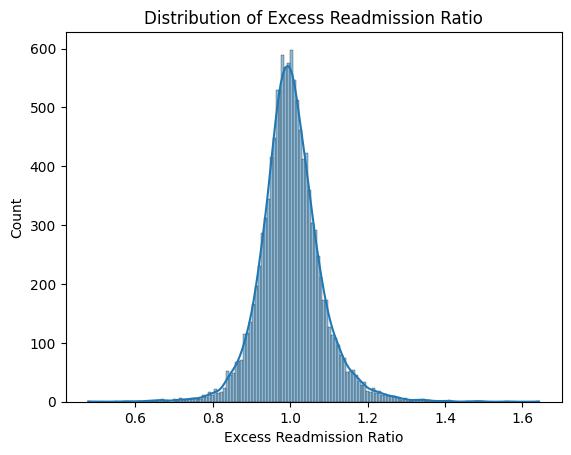

In [18]:
#Visual Analysis
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.histplot(df['Excess Readmission Ratio'], kde=True)
plt.title("Distribution of Excess Readmission Ratio")
plt.show()


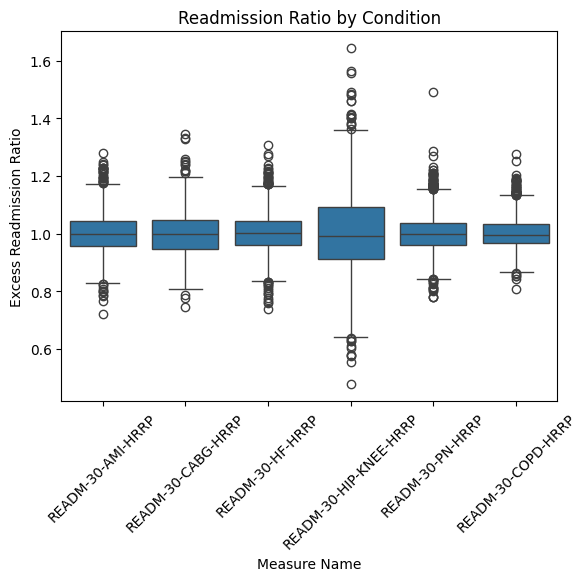

In [19]:
plt.figure()
sns.boxplot(data=df, x='Measure Name', y='Excess Readmission Ratio')
plt.xticks(rotation=45)
plt.title("Readmission Ratio by Condition")
plt.show()


In [20]:
#Correlation Analysis
df[['Excess Readmission Ratio','Predicted Readmission Rate',
    'Expected Readmission Rate','Number of Discharges','Number of Readmissions']].corr()

,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Discharges,Number of Readmissions
Excess Readmission Ratio,1.000000,0.203273,0.021479,-0.144654,0.080604
Predicted Readmission Rate,0.203273,1.000000,0.978263,-0.018601,0.303146
Expected Readmission Rate,0.021479,0.978263,1.000000,0.009785,0.285670
Number of Discharges,-0.144654,-0.018601,0.009785,1.000000,0.894155
Number of Readmissions,0.080604,0.303146,0.285670,0.894155,1.000000


In [21]:
#Hypothesis Testing
#Do case volumes affect readmission ratio?
from scipy.stats import pearsonr

pearsonr(df['Number of Discharges'], df['Excess Readmission Ratio'])


PearsonRResult(statistic=np.float64(nan), pvalue=np.float64(nan))

In [22]:
#Regression Model
import statsmodels.api as sm

X = df[['Expected Readmission Rate','Predicted Readmission Rate','Number of Discharges']]
X = sm.add_constant(X)

y = df['Excess Readmission Ratio']

model = sm.OLS(y, X, missing='drop').fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                               
====================================================================================
Dep. Variable:     Excess Readmission Ratio   R-squared:                       0.851
Model:                                  OLS   Adj. R-squared:                  0.851
Method:                       Least Squares   F-statistic:                 1.540e+04
Date:                      Tue, 02 Dec 2025   Prob (F-statistic):               0.00
Time:                              12:17:31   Log-Likelihood:                 16889.
No. Observations:                      8121   AIC:                        -3.377e+04
Df Residuals:                          8117   BIC:                        -3.374e+04
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          1.0194      0.002    639.278      0.000       1.016       1.023
Expected Readmission Rate     -0.0624      0.000   -203.749      0.000      -0.063      -0.062
Predicted Readmission Rate     0.0615      0.000    212.237      0.000       0.061       0.062
Number of Discharges       -1.756e-05   1.27e-06    -13.832      0.000      -2e-05   -1.51e-05
==============================================================================
Omnibus:                     3446.243   Durbin-Watson:                   1.917
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           854717.191
Skew:                           0.840   Prob(JB):                         0.00
Kurtosis:                      53.231   Cond. No.                     1.86e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.86e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [23]:
#Clustering Hospitals (Risk Segmentation)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = df[['Excess Readmission Ratio', 'Number of Readmissions']]
features = features.dropna()

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=0)
features['Cluster'] = kmeans.fit_predict(scaled)

features['Cluster'].value_counts()


Cluster
0    4062
2    3275
1     784
Name: count, dtype: int64